<a href="https://colab.research.google.com/github/Pranayshukla0610/ML-projects-portfolio/blob/main/Real_Time_Stock_Market_Business_Analytics_%26_Price_Forecasting_using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
ticker = 'NVDA'

df = yf.download(
    ticker,
    start = '2020-01-01',
    end = '2026-05-01'
)

[*********************100%***********************]  1 of 1 completed


In [3]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,
2020-01-02,5.970753,5.970753,5.891363,5.941884,237536000
2020-01-03,5.875187,5.918989,5.826158,5.851046,205384000
2020-01-06,5.899826,5.905052,5.755728,5.781860,262636000
2020-01-07,5.971252,6.017045,5.883151,5.928197,314856000
2020-01-08,5.982452,6.023766,5.926953,5.967022,277108000


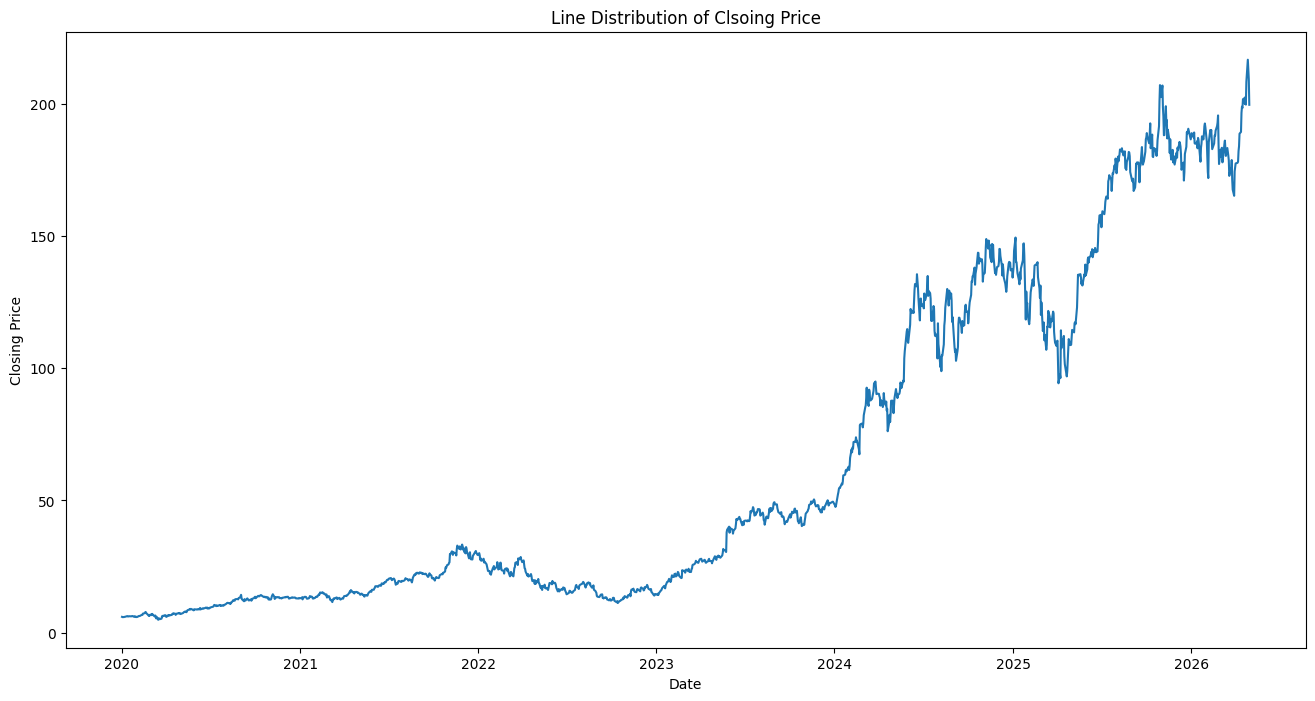

In [4]:
plt.figure(figsize=(16,8))
sns.lineplot(
    x = df.index,
    y = df['Close'].squeeze()
)
plt.title('Line Distribution of Clsoing Price')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.show()

###Strong upward trend during AI boom

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1590 entries, 2020-01-02 to 2026-04-30
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, NVDA)   1590 non-null   float64
 1   (High, NVDA)    1590 non-null   float64
 2   (Low, NVDA)     1590 non-null   float64
 3   (Open, NVDA)    1590 non-null   float64
 4   (Volume, NVDA)  1590 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 74.5 KB


In [6]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
count,1590.000000,1590.000000,1590.000000,1590.000000,1.590000e+03
mean,64.218739,65.284613,63.053901,64.225649,3.971209e+08
std,62.141085,63.054956,61.173833,62.192178,1.969342e+08
min,4.890823,5.228002,4.499359,4.982963,6.552850e+07
25%,15.129024,15.324501,14.833619,15.084543,2.361927e+08
50%,28.021100,28.491192,27.339674,27.882352,3.721935e+08
75%,118.299177,121.404238,116.422386,118.554762,5.130832e+08
max,216.610001,216.830002,208.199997,212.699997,1.543911e+09


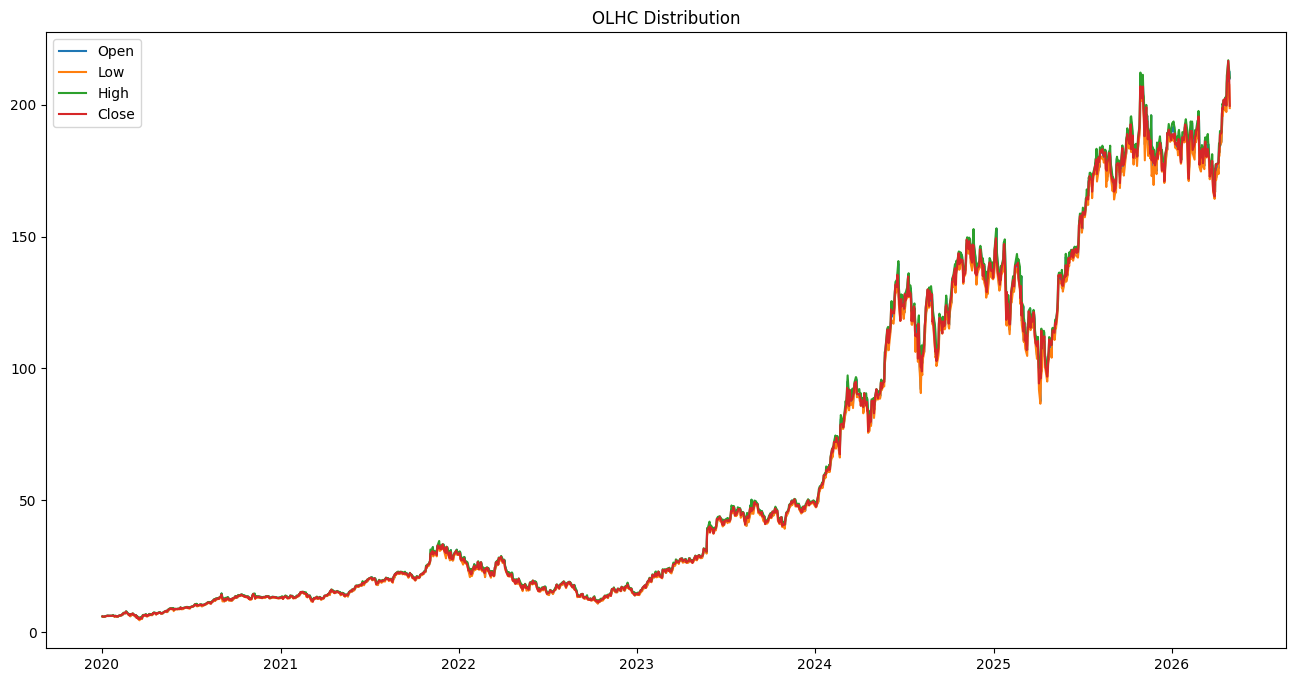

In [7]:
plt.figure(figsize=(16,8))

plt.plot(df['Open'],label='Open')

plt.plot(df['Low'],label='Low')

plt.plot(df['High'],label='High')

plt.plot(df['Close'],label='Close')

plt.title('OLHC Distribution')
plt.legend()
plt.show()

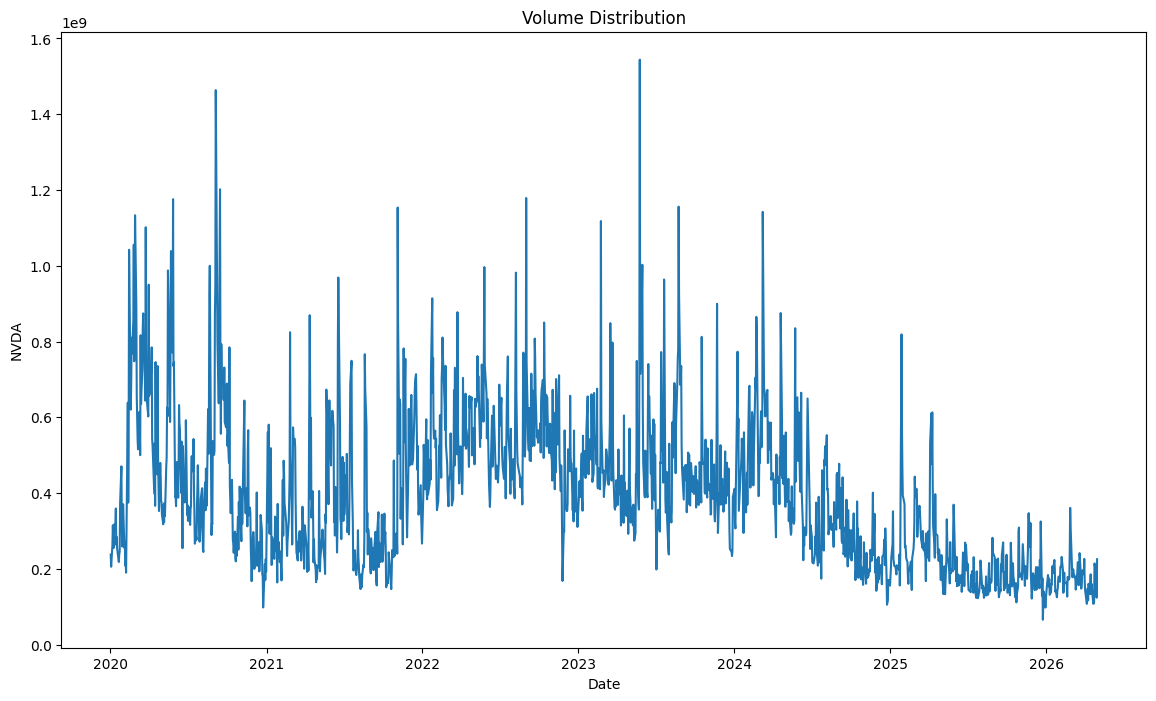

In [8]:
plt.figure(figsize=(14,8))

sns.lineplot(
    x = df.index,
    y = df['Volume'].squeeze()
)

plt.title('Volume Distribution')
plt.show()

###Volume tells us:

###“How strongly investors believe in price movement.”



In [9]:
df['Daily_Return'] = df['Close'].pct_change()

###Returns measure profitability
###Returns measure investment performance

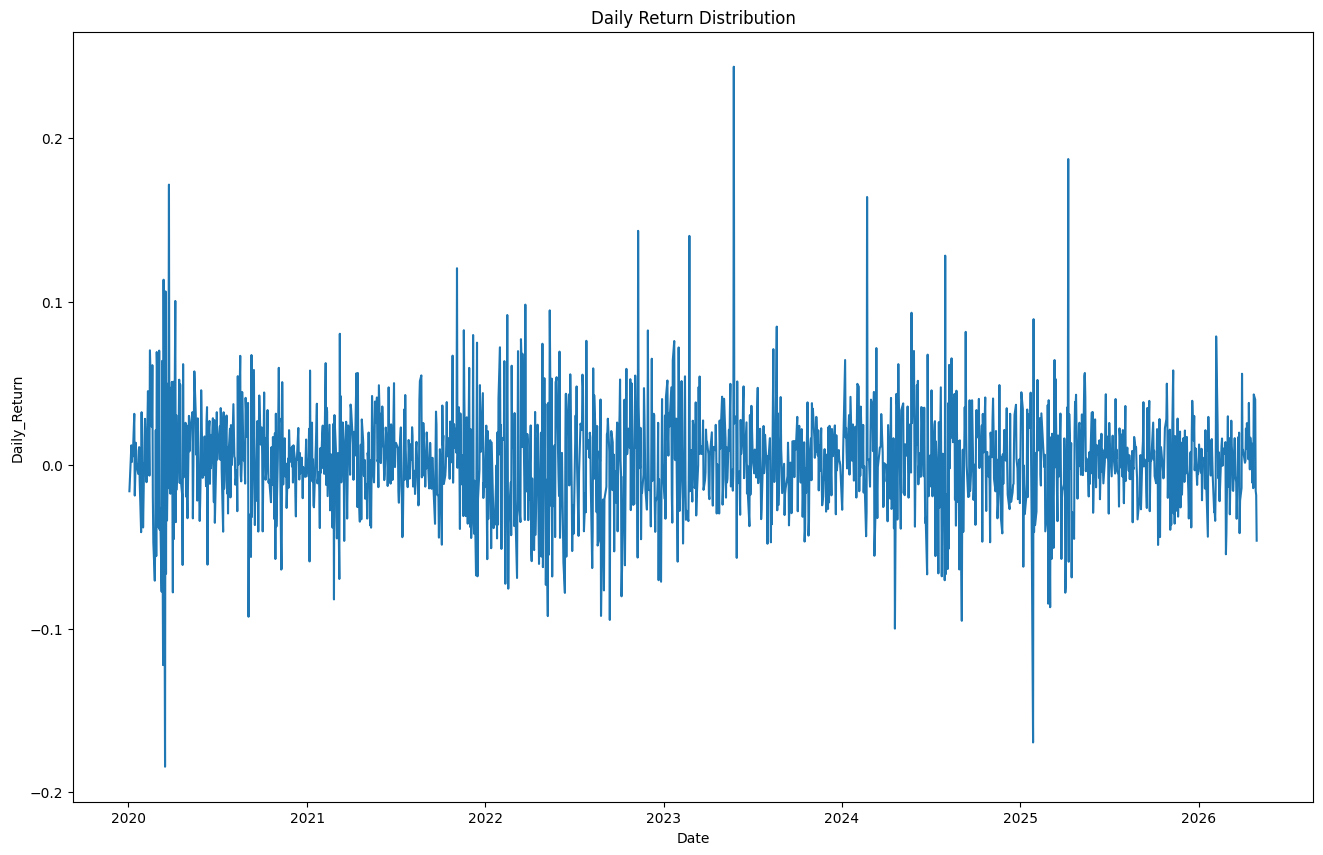

In [10]:
plt.figure(figsize=(16,10))

sns.lineplot(
    x = df.index,
    y = df['Daily_Return'].squeeze()
)

plt.title('Daily Return Distribution')
plt.show(
)

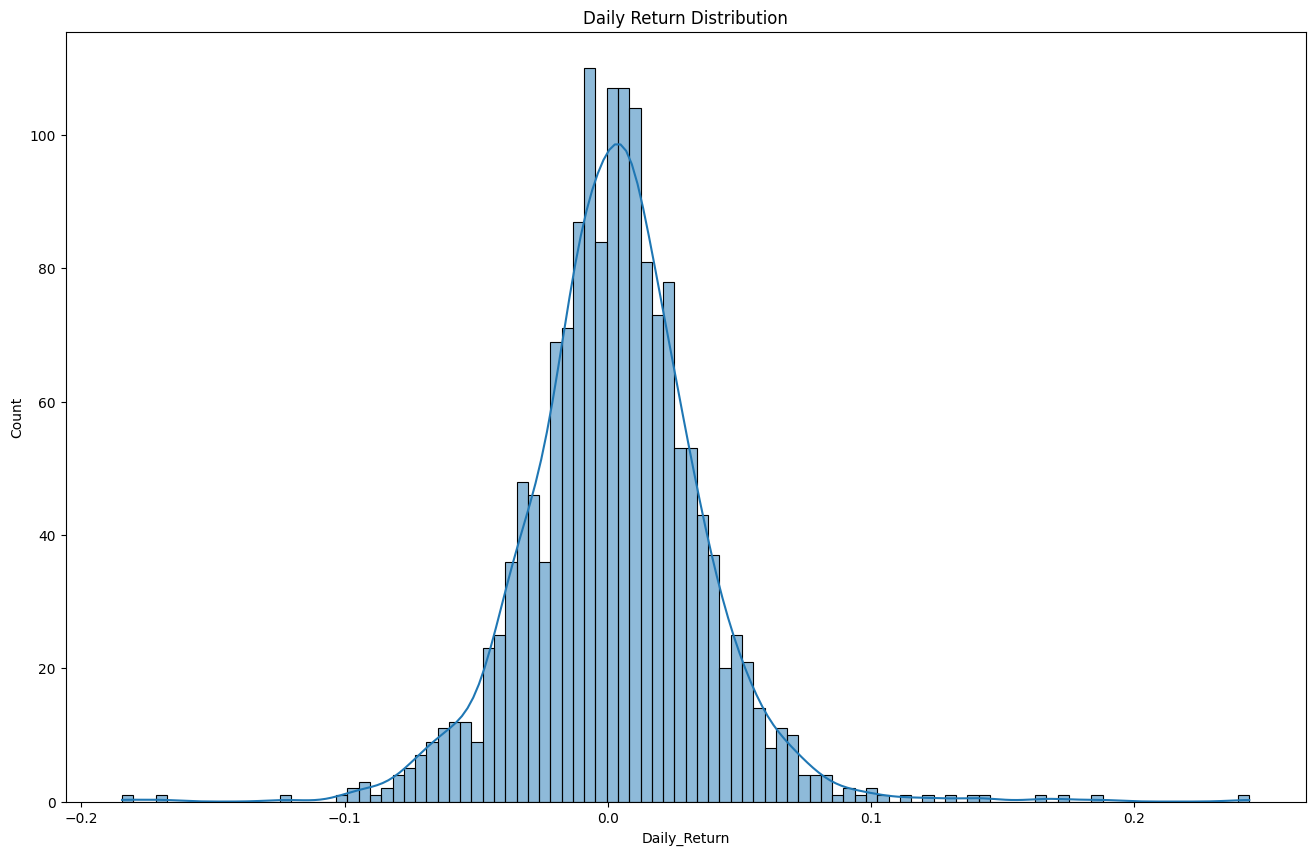

In [12]:
plt.figure(figsize=(16,10))

sns.histplot(
    df['Daily_Return'],
    bins = 100,
    kde = True
)

plt.title('Daily Return Distribution')
plt.show(
)

In [15]:
df['Volatility'] = (
    df['Daily_Return'].
    rolling(30)
    .std()
)

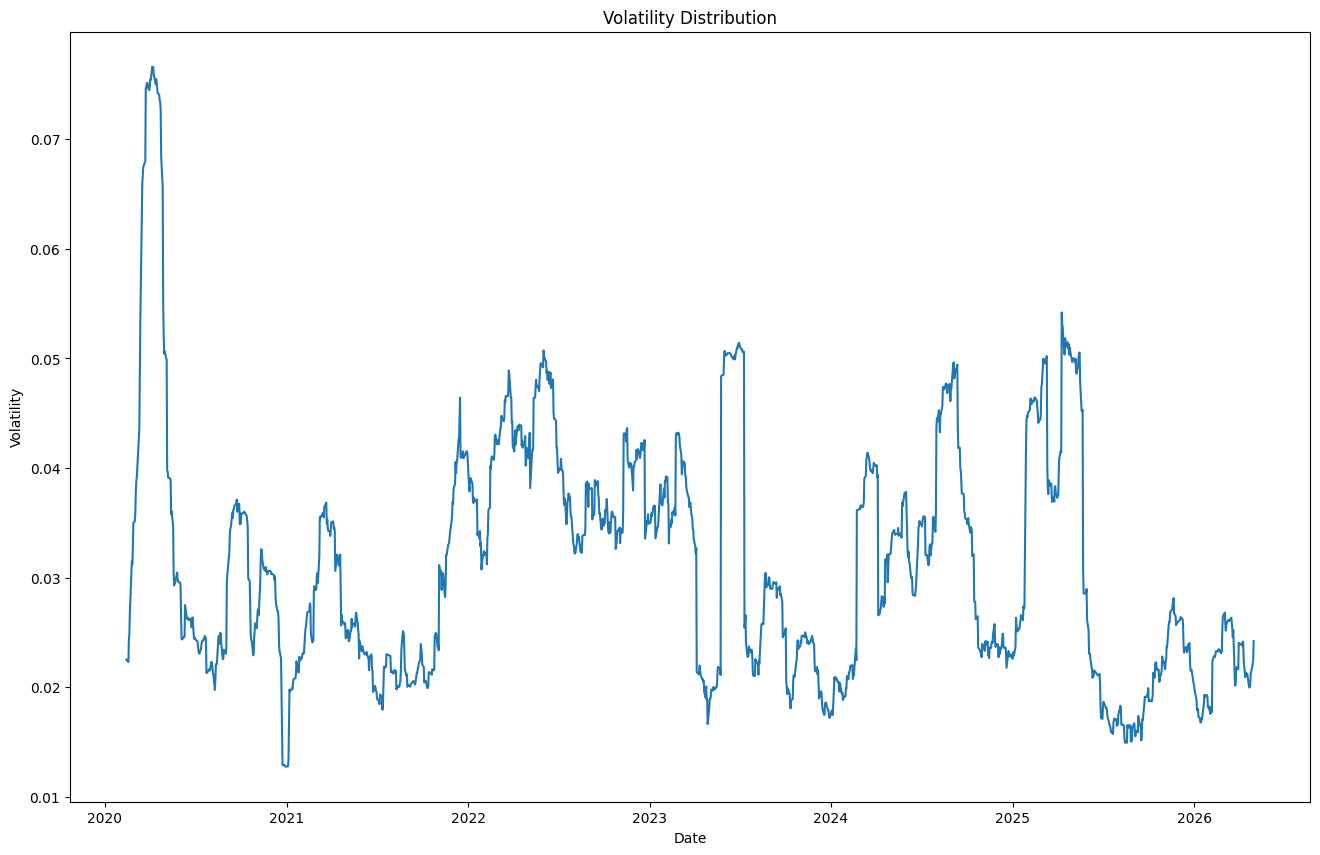

In [16]:
plt.figure(figsize=(16,10))

sns.lineplot(
    x = df.index,
    y = df['Volatility'].squeeze()
)

plt.title('Volatility Distribution')
plt.show(
)

###High volatility periods often align with:

###Event:	Why
###Earnings announcements:	Uncertainty
###Interest rate hikes:	Growth stock pressure
###AI market hype:	Speculation

In [17]:
df['MA30'] = (
    df['Close'].
    rolling(30)
    .mean()
)

df['MA100'] = (
    df['Close'].
    rolling(100)
    .mean()
)

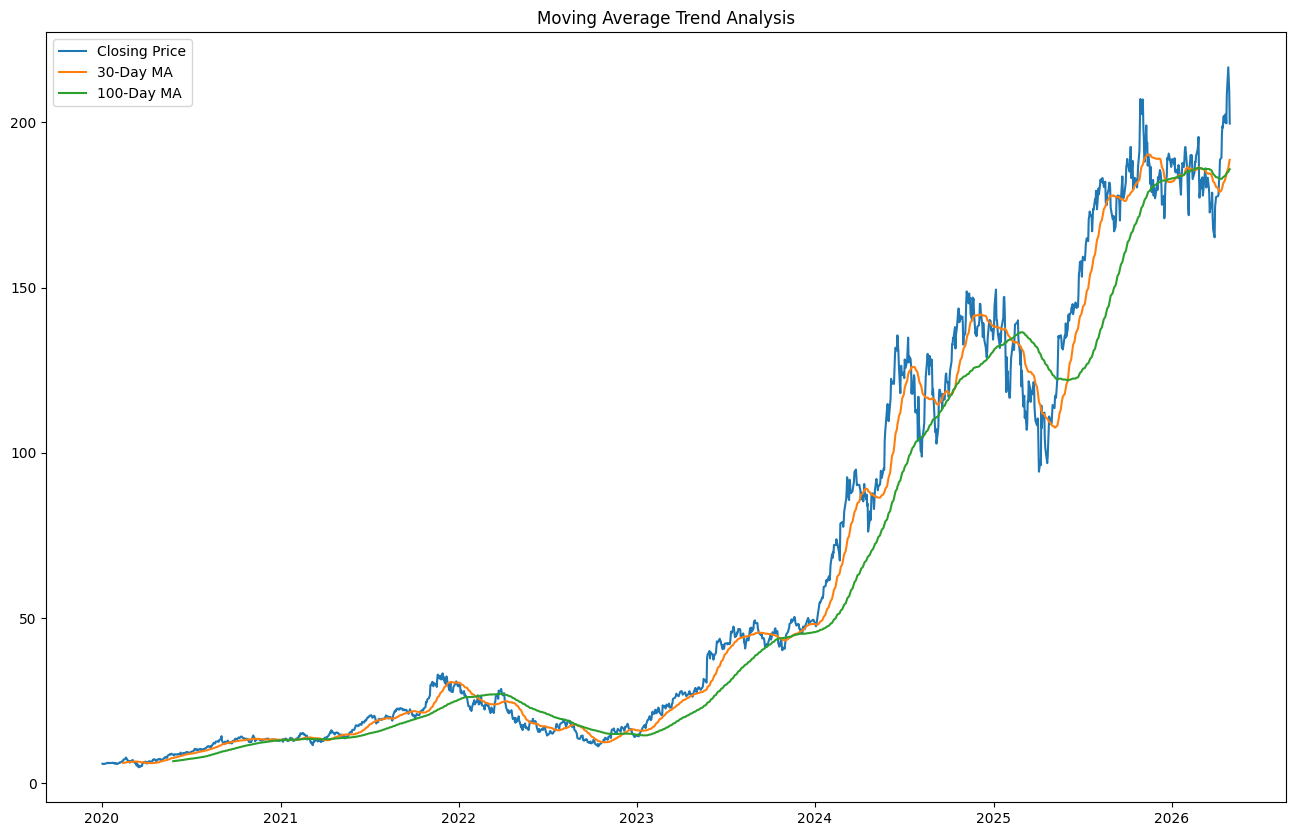

In [18]:
plt.figure(figsize=(16,10))

plt.plot(df['Close'],label='Closing Price')

plt.plot(df['MA30'], label='30-Day MA')

plt.plot(df['MA100'],label='100-Day MA')

plt.legend()

plt.title('Moving Average Trend Analysis')

plt.show()

###Moving averages help identify:

###Signal:	Meaning
###Short MA above Long MA:	Bullish trend
###Short MA below Long MA:	Bearish trend

###If NVIDIA remains above long-term moving averages:

###It indicates:

###Strong institutional confidence
###Long-term bullish trend

In [19]:
df['Lag_1'] = df['Close'].shift(1)

df['Lag_7'] = df['Close'].shift(7)

df['Volume Changes'] = df['Volume'].pct_change()

df = df.dropna()

In [21]:
features = [
    'Open',
    'High',
    'Low',
    'Volume',
    'Volatility',
    'Lag_1',
    'Lag_7',
    'Volume Changes',
    'MA30',
    'MA100'
]

X = df[features]

y = df['Close']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

###WHY NO SHUFFLING?

###Financial data is:

###Time-dependent.

###Future information must not leak into the past.

In [24]:
lr = LinearRegression()

lr.fit(X_train,y_train)

lr_pred = lr.predict(X_test)

In [25]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

In [27]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [28]:
def evaluate(y_true, pred, model):

    print(f"\n{model}")

    print(
        "MAE:",
        mean_absolute_error(y_true, pred)
    )

    print(
        "RMSE:",
        np.sqrt(mean_squared_error(y_true, pred))
    )

    print(
        "R2:",
        r2_score(y_true, pred)
    )

In [29]:
evaluate(y_test, lr_pred, 'Linear Regression')

evaluate(y_test, rf_pred, 'Random Forest')

evaluate(y_test, xgb_pred, 'XGBoost')


Linear Regression
MAE: 1.0316230704153335
RMSE: 1.37684446201898
R2: 0.9978439891823685

Random Forest
MAE: 25.155891307597166
RMSE: 30.55913372392158
R2: -0.06209471843326564

XGBoost
MAE: 26.2647647857666
RMSE: 31.819823375813524
R2: -0.15153396129608154


###The model is not truly forecasting future prices.

###It is using highly related same-day market information.

###Why Random Forest & XGBoost Performed Poorly

###This is VERY important to understand.
###Financial markets are sequential.

###Tree-based models sometimes struggle when:

###Market regime changes
###Trends shift rapidly
###Dataset structure weak

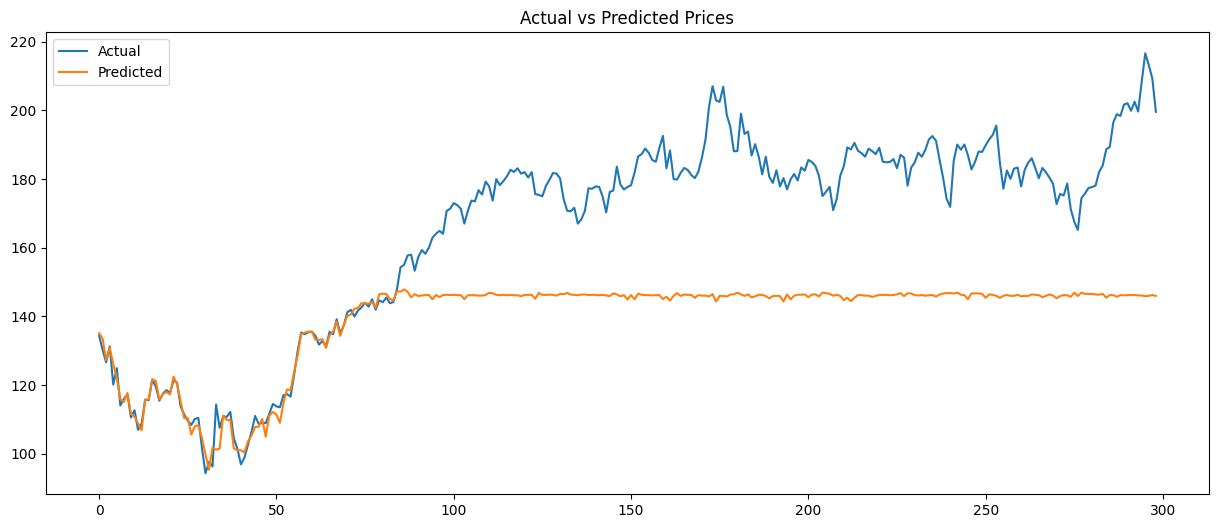

In [30]:
plt.figure(figsize=(15,6))

plt.plot(
    y_test.values,
    label='Actual'
)

plt.plot(
    xgb_pred,
    label='Predicted'
)

plt.legend()

plt.title('Actual vs Predicted Prices')

plt.show()

In [31]:
importance = pd.DataFrame({
    'Feature':features,
    'Importance':xgb.feature_importances_
})

importance = importance.sort_values(
    by = 'Importance',
    ascending = False
)

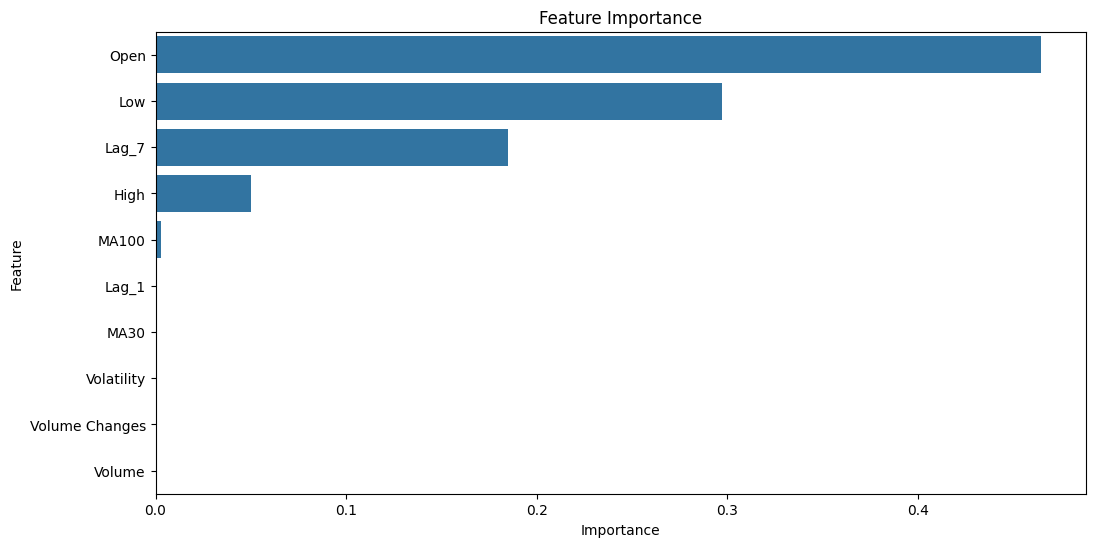

In [32]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title('Feature Importance')

plt.show()